<a href="https://colab.research.google.com/github/KatherinePalaciosaCortez/KatherinePalaciosCortez/blob/main/casopractico/notebooks/prestige.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/KatherinePalaciosaCortez/casopractico/refs/heads/main/data/raw/Prestige_modificado.csv", sep=";")

In [ ]:
 # ACTIVIDAD 1 — Preparación e inspección del dataset
print(f"\nDimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

print("\nPrimeras 5 filas:")
print(df.head().to_string())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

print("\nEstadística descriptiva:")
print(df.describe().round(2).to_string())




Dimensiones: 102 filas × 7 columnas

Primeras 5 filas:
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1

Tipos de datos:
occupation     object
education     float64
income          int64
women         float64
prestige      float64
census          int64
type_num        int64
dtype: object

Valores nulos por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

Registros duplicados: 0

Estadística descriptiva:
       education    income   women  prestige   census  type_num
count     102.00    102.00  1

In [ ]:
#nálisis de correlación


variables_numericas = df[["education", "income", "women", "prestige"]]
matriz_correlacion = variables_numericas.corr()

print("\nMatriz de correlación completa:")
print(matriz_correlacion.round(3).to_string())

print("\nCorrelaciones con 'prestige' (ordenadas de mayor a menor):")
print(matriz_correlacion["prestige"].sort_values(ascending=False).round(3).to_string())




Matriz de correlación completa:
           education  income  women  prestige
education      1.000   0.578  0.062     0.850
income         0.578   1.000 -0.441     0.715
women          0.062  -0.441  1.000    -0.118
prestige       0.850   0.715 -0.118     1.000

Correlaciones con 'prestige' (ordenadas de mayor a menor):
prestige     1.000
education    0.850
income       0.715
women       -0.118


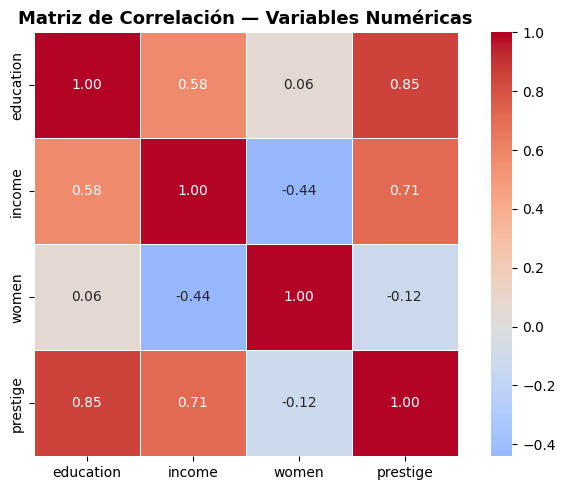

In [ ]:
# Gráfico 1: Heatmap de correlación
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matriz de Correlación — Variables Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


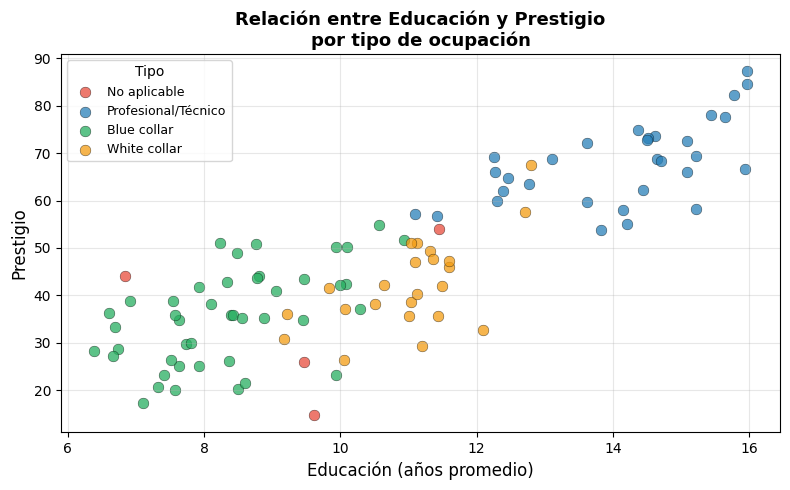

In [ ]:
plt.figure(figsize=(8, 5))
for tipo, grupo in df.groupby("type_num"):
    plt.scatter(grupo["education"], grupo["prestige"],
                color=colores[tipo], label=etiquetas[tipo],
                alpha=0.75, edgecolors="k", linewidths=0.3, s=60)
plt.xlabel("Educación (años promedio)", fontsize=12)
plt.ylabel("Prestigio", fontsize=12)
plt.title("Relación entre Educación y Prestigio\npor tipo de ocupación",
          fontsize=13, fontweight="bold")
plt.legend(title="Tipo", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_education_prestige.png", dpi=150)
plt.show()


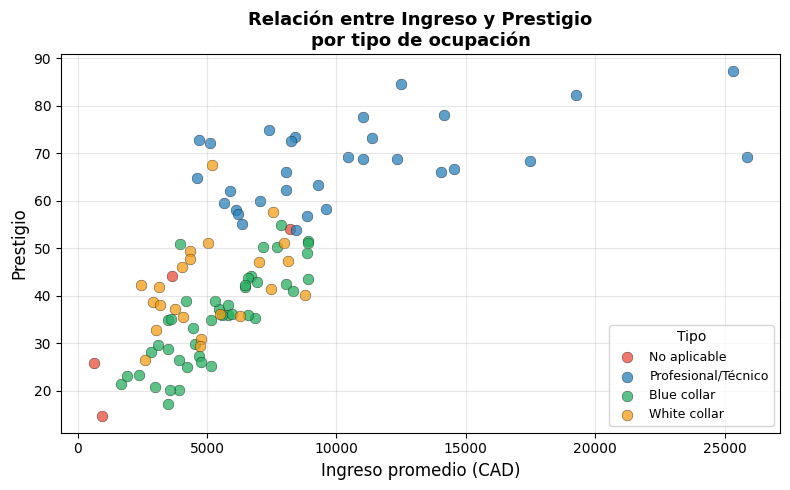

In [ ]:
# Gráfico 3: Income vs Prestige
# Definir colores y etiquetas para los tipos de ocupación
colores = {0: "#e74c3c", 1: "#2980b9", 2: "#27ae60", 3: "#f39c12"}
etiquetas = {0: "No aplicable", 1: "Profesional/Técnico", 2: "Blue collar", 3: "White collar"}

plt.figure(figsize=(8, 5))
for tipo, grupo in df.groupby("type_num"):
    plt.scatter(grupo["income"], grupo["prestige"],
                color=colores[tipo], label=etiquetas[tipo],
                alpha=0.75, edgecolors="k", linewidths=0.3, s=60)
plt.xlabel("Ingreso promedio (CAD)", fontsize=12)
plt.ylabel("Prestigio", fontsize=12)
plt.title("Relación entre Ingreso y Prestigio\npor tipo de ocupación",
          fontsize=13, fontweight="bold")
plt.legend(title="Tipo", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


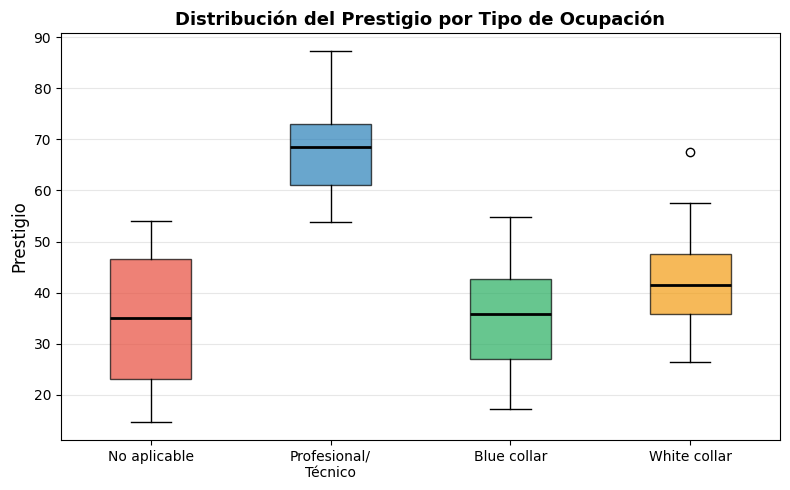

In [ ]:
# Gráfico 4: Boxplot de prestigio por tipo
plt.figure(figsize=(8, 5))
nombres_tipo = ["No aplicable", "Profesional/\nTécnico", "Blue collar", "White collar"]
datos_por_tipo = [df[df["type_num"] == t]["prestige"].values for t in [0, 1, 2, 3]]
colores_box = ["#e74c3c", "#2980b9", "#27ae60", "#f39c12"]

bp = plt.boxplot(datos_por_tipo, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks([1, 2, 3, 4], nombres_tipo, fontsize=10)
plt.ylabel("Prestigio", fontsize=12)
plt.title("Distribución del Prestigio por Tipo de Ocupación",
          fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_boxplot_tipo.png", dpi=150)
plt.show()


In [ ]:
 #ACTIVIDAD 4  Clustering K-Means (k=4 y k=5)

In [ ]:
# ── Modelo k=4 ────────────────────────────────────────────────────────────────

# escalado de variables
columnas_cluster = ["education", "income", "women", "prestige", "type_num"]
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)
print(f"\nVariables para clustering: {columnas_cluster}")
print("Datos escalados con StandardScaler.")

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster_4"] = modelo_k4.fit_predict(X_escalado)
score_k4 = silhouette_score(X_escalado, df["Cluster_4"])

print("\n" + "-" * 40)
print("  MODELO K-MEANS — k = 4 CLÚSTERES")
print("-" * 40)
print(f"Silhouette Score: {score_k4:.4f}")
print("\nDistribución de ocupaciones:")
print(df["Cluster_4"].value_counts().sort_index().to_string())
print("\nCentroides (promedios por clúster):")
print(df.groupby("Cluster_4")[columnas_cluster].mean().round(2).to_string())

print("\nMuestra de ocupaciones por clúster (k=4):")
for c in sorted(df["Cluster_4"].unique()):
    occ = df[df["Cluster_4"] == c]["occupation"].values[:4]
    print(f"  Clúster {c}: {', '.join(occ)}")


Variables para clustering: ['education', 'income', 'women', 'prestige', 'type_num']
Datos escalados con StandardScaler.

----------------------------------------
  MODELO K-MEANS — k = 4 CLÚSTERES
----------------------------------------
Silhouette Score: 0.3788

Distribución de ocupaciones:
Cluster_4
0    20
1    47
2    23
3    12

Centroides (promedios por clúster):
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

Muestra de ocupaciones por clúster (k=4):
  Clúster 0: accountants, purchasing.officers, chemists, biologists
  Clúster 1: radio.tv.announcers, shipping.clerks, mail.carriers, sales.supervisors
  Clúster 2: nursing.aides, medical.technicians, secretaries, typists
  Clúster 3: g

In [ ]:
# Modelo k=4
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster_4"] = modelo_k4.fit_predict(X_escalado)
score_k4 = silhouette_score(X_escalado, df["Cluster_4"])

print("\n" + "-" * 40)
print("  MODELO K-MEANS — k = 4 CLÚSTERES")
print("-" * 40)
print(f"Silhouette Score: {score_k4:.4f}")
print("\nDistribución de ocupaciones:")
print(df["Cluster_4"].value_counts().sort_index().to_string())
print("\nCentroides (promedios por clúster):")
print(df.groupby("Cluster_4")[columnas_cluster].mean().round(2).to_string())

print("\nMuestra de ocupaciones por clúster (k=4):")
for c in sorted(df["Cluster_4"].unique()):
    occ = df[df["Cluster_4"] == c]["occupation"].values[:4]
    print(f"  Clúster {c}: {', '.join(occ)}")


----------------------------------------
  MODELO K-MEANS — k = 4 CLÚSTERES
----------------------------------------
Silhouette Score: 0.3788

Distribución de ocupaciones:
Cluster_4
0    20
1    47
2    23
3    12

Centroides (promedios por clúster):
           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00

Muestra de ocupaciones por clúster (k=4):
  Clúster 0: accountants, purchasing.officers, chemists, biologists
  Clúster 1: radio.tv.announcers, shipping.clerks, mail.carriers, sales.supervisors
  Clúster 2: nursing.aides, medical.technicians, secretaries, typists
  Clúster 3: gov.administrators, general.managers, physicists, architects


In [ ]:
# Modelo k=5
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster_5"] = modelo_k5.fit_predict(X_escalado)
score_k5 = silhouette_score(X_escalado, df["Cluster_5"])

print("\n" + "-" * 40)
print("  MODELO K-MEANS — k = 5 CLÚSTERES")
print("-" * 40)
print(f"Silhouette Score: {score_k5:.4f}")
print("\nDistribución de ocupaciones:")
print(df["Cluster_5"].value_counts().sort_index().to_string())
print("\nCentroides (promedios por clúster):")
print(df.groupby("Cluster_5")[columnas_cluster].mean().round(2).to_string())

print("\nMuestra de ocupaciones por clúster (k=5):")
for c in sorted(df["Cluster_5"].unique()):
    occ = df[df["Cluster_5"] == c]["occupation"].values[:4]
    print(f"  Clúster {c}: {', '.join(occ)}")



----------------------------------------
  MODELO K-MEANS — k = 5 CLÚSTERES
----------------------------------------
Silhouette Score: 0.3342

Distribución de ocupaciones:
Cluster_5
0    17
1    32
2    20
3    21
4    12

Centroides (promedios por clúster):
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00

Muestra de ocupaciones por clúster (k=5):
  Clúster 0: nursing.aides, medical.technicians, secretaries, typists
  Clúster 1: radio.tv.announcers, shipping.clerks, mail.carriers, sales.supervisors
  Clúster 2: accountants, purchasing.officers, chemists, biologists
  Clúster 3: newsboys, service.station.attendant, cooks, bartenders
 